# Cross-Regional Housing Price Prediction & Generalization Study
## Phase 7 — Generalization Test (Ames → King County)

### Phase 7 — Cross-Regional Transfer Learning

Goal: Test whether models trained on Iowa (Ames) housing data can predict Seattle (King County) prices.

Three-part analysis:
- **Apply Ames Model**: Raw transfer performance without retraining
- **Feature Shift (SHAP)**: Compare feature importance between regions
- **Which Model Transfers**: Linear vs Random Forest vs XGBoost comparison
- **Bonus**: Fine-tune best model on King County data

Key Challenges:
1. Feature mismatch: Ames has 174 preprocessed features, King County has 21 raw features
2. Geographic context: Iowa (midwest, lower cost) vs Seattle (tech hub, high cost)
3. Price distribution shift: Different market dynamics

Expected Outcome: Poor transfer performance demonstrates real-world distribution shift challenges.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Load utils
with open('/content/drive/MyDrive/Housing_Project/utils.py', 'r') as f:
    exec(f.read())

# Load both datasets
ames, kc = load_raw()

print("Ames columns:", ames.shape[1])
print("King County columns:", kc.shape[1])
print("\nKing County features:")
print(kc.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ames columns: 82
King County columns: 21

King County features:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


### 7.1 Load Ames Processed Data and Best Model


In [ ]:
# Load preprocessed Ames data
X_train = load_processed('X_train.csv')
print(f"model expects {X_train.shape[1]} features")
print(f"\nFirst 10 feature names:")
print(X_train.columns[:10].tolist())

model expects 174 features

First 10 feature names:
['Order', 'PID', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Slope', 'Neighborhood', 'Overall Qual', 'Overall Cond', 'Year Built']


In [ ]:
import pickle

with open('/content/drive/MyDrive/Housing_Project/data/models/best_xgb.pkl', 'rb') as f:
    best_xgb = pickle.load(f)

print("Model loaded successfully")
print(f"Model expects {best_xgb.n_features_in_} features")

Model loaded successfully
Model expects 174 features


### 7.2 King County Feature Mapping Strategy

King County → Ames feature transformation:
- Direct mapping: 9 features (sqft_living → Gr Liv Area, grade → Overall Qual, etc.)
- Fill remaining 165 features with Ames training set medians

This severe feature mismatch is the primary challenge for transfer learning.

In [ ]:
# King County → Ames feature mapping
kc_to_ames_map = {
    'sqft_living': 'Gr Liv Area',
    'sqft_basement': 'Total Bsmt SF',
    'sqft_above': '1st Flr SF',  # approximation
    'sqft_lot': 'Lot Area',
    'bedrooms': 'Bedroom AbvGr',
    'bathrooms': None,  # need to split into Full Bath + Half Bath
    'floors': None,  # no direct equivalent
    'yr_built': 'Year Built',
    'yr_renovated': 'Year Remod/Add',
    'grade': 'Overall Qual',  # quality rating
    'condition': 'Overall Cond',
    'waterfront': None,  # create as binary feature
    'view': None,  # create as ordinal
}

print("Features with direct mapping:", sum(1 for v in kc_to_ames_map.values() if v is not None))
print("\nFeatures needing custom handling:", sum(1 for v in kc_to_ames_map.values() if v is None))

Features with direct mapping: 9

Features needing custom handling: 4


In [ ]:
X_train = load_processed('X_train.csv')
print("Total features:", len(X_train.columns))
print("\nFirst 30 columns:")
print(X_train.columns[:30].tolist())

Total features: 174

First 30 columns:
['Order', 'PID', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Slope', 'Neighborhood', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating QC', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area']


### 7.3 Apply Ames Model — Raw Transfer Performance


 ### Transform King County data to match Ames 174-feature structure.
    
    Strategy:
    1. Create empty DataFrame with Ames column structure
    2. Map King County features where possible
    3. Fill remaining features with Ames training medians/modes

In [ ]:
def prepare_kc_for_ames_model(kc_raw, X_train):
    import numpy as np

    # Step 1: Create empty DataFrame with correct structure
    kc_processed = pd.DataFrame(columns=X_train.columns, index=kc_raw.index)

    # Step 2: Direct feature mapping
    feature_map = {
        'Lot Area': 'sqft_lot',
        'Year Built': 'yr_built',
        'Gr Liv Area': 'sqft_living',
        'Total Bsmt SF': 'sqft_basement',
        '1st Flr SF': 'sqft_above',
        'Bedroom AbvGr': 'bedrooms',
        'Overall Qual': 'grade',
        'Overall Cond': 'condition',
    }

    for ames_col, kc_col in feature_map.items():
        if kc_col in kc_raw.columns:
            kc_processed[ames_col] = kc_raw[kc_col].values

    # Step 3: Fill remaining with Ames training defaults
    for col in kc_processed.columns:
        if kc_processed[col].isnull().all():  # column is empty
            kc_processed[col] = X_train[col].median()

    return kc_processed

# Test it
kc_test = prepare_kc_for_ames_model(kc.head(), X_train)
print("King County processed shape:", kc_test.shape)
print("Any missing values:", kc_test.isnull().sum().sum())

King County processed shape: (5, 174)
Any missing values: 0


In [ ]:
# Process full King County dataset
kc_processed = prepare_kc_for_ames_model(kc, X_train)
print(f"Processed King County: {kc_processed.shape}")

# Apply Ames-trained XGBoost model to King County
kc_predictions = best_xgb.predict(kc_processed)

# Compare with actual King County prices
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

kc_actual = kc['price'].values
kc_rmse = np.sqrt(mean_squared_error(kc_actual, kc_predictions))
kc_r2 = r2_score(kc_actual, kc_predictions)

print(f"\nAmes model on King County data:")
print(f"RMSE: ${kc_rmse:,.0f}")
print(f"R²: {kc_r2:.3f}")

print(f"\nFor comparison - Ames model on Ames test data:")
print(f"RMSE: $22,108")
print(f"R²: 0.931")

Processed King County: (21613, 174)

Ames model on King County data:
RMSE: $492,187
R²: -0.797

For comparison - Ames model on Ames test data:
RMSE: $22,108
R²: 0.931


### Finding:

Transfer performance is severely degraded (R² = -0.797, meaning worse than predicting the mean). This demonstrates that models trained on one geographic region with specific features do not generalize to other regions without adaptation.

### 7.4 Which Model Transfers Best? (Linear vs RF vs XGBoost)


In [ ]:
# Analysis of transfer failure
print("Why Cross-Regional Transfer Failed\n")

print("1. Feature Availability:")
print(f"   - Features mapped from King County: 9")
print(f"   - Features filled with Ames defaults: 165")
print(f"   - Percentage of real features: {9/174*100:.1f}%\n")

print("2. Price Distribution Shift:")
kc_price_stats = kc['price'].describe()
print(f"   King County median price: ${kc['price'].median():,.0f}")
print(f"   King County mean price: ${kc['price'].mean():,.0f}")
print(f"   (Ames mean was ~$180k)\n")

print("3. Geographic Context:")
print("   - Ames: Iowa, midwest, lower cost of living")
print("   - King County: Seattle, tech hub, high cost of living")

Why Cross-Regional Transfer Failed

1. Feature Availability:
   - Features mapped from King County: 9
   - Features filled with Ames defaults: 165
   - Percentage of real features: 5.2%

2. Price Distribution Shift:
   King County median price: $450,000
   King County mean price: $540,088
   (Ames mean was ~$180k)

3. Geographic Context:
   - Ames: Iowa, midwest, lower cost of living
   - King County: Seattle, tech hub, high cost of living


In [ ]:
# Load all three models for comparison
import pickle

# Load Linear Regression
with open('/content/drive/MyDrive/Housing_Project/data/models/best_xgb.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# We need to save Linear and RF models from Phase 4
# For now, let's retrain them quickly on the same data

# Load processed Ames data
X_train = load_processed('X_train.csv')
X_test = load_processed('X_test.csv')
y_train = load_processed('y_train.csv').squeeze()
y_test = load_processed('y_test.csv').squeeze()

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Train Linear and RF
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(max_depth=7, min_samples_split=2, n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("All three models ready for transfer test")

All three models ready for transfer test


In [ ]:
# Test all three models on King County
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Predictions from all three models
linear_pred = linear_model.predict(kc_processed)
rf_pred = rf_model.predict(kc_processed)
xgb_pred = xgb_model.predict(kc_processed)

# Calculate metrics
kc_actual = kc['price'].values

results = []
for name, pred in [('Linear Regression', linear_pred),
                   ('Random Forest', rf_pred),
                   ('XGBoost', xgb_pred)]:
    rmse = np.sqrt(mean_squared_error(kc_actual, pred))
    mae = mean_absolute_error(kc_actual, pred)
    r2 = r2_score(kc_actual, pred)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

# Display results
transfer_results = pd.DataFrame(results)
print("=== Transfer Performance (Ames → King County) ===\n")
print(transfer_results.to_string(index=False))

print("\n=== Original Performance (Ames test set) ===")
print("XGBoost: RMSE $22,108, R² 0.931")
print("Random Forest: RMSE $24,255, R² 0.926")
print("Linear Regression: RMSE $31,268, R² 0.878")

=== Transfer Performance (Ames → King County) ===

            Model         RMSE          MAE             R2
Linear Regression 1.708285e+08 9.249528e+07 -216523.675695
    Random Forest 5.105479e+05 3.566005e+05      -0.934016
          XGBoost 4.921873e+05 3.314756e+05      -0.797412

=== Original Performance (Ames test set) ===
XGBoost: RMSE $22,108, R² 0.931
Random Forest: RMSE $24,255, R² 0.926
Linear Regression: RMSE $31,268, R² 0.878


In [ ]:
# Format the results properly
print("=== Transfer Performance (Ames → King County) ===\n")
for i, row in transfer_results.iterrows():
    print(f"{row['Model']}:")
    print(f"  RMSE: ${row['RMSE']:,.0f}")
    print(f"  MAE: ${row['MAE']:,.0f}")
    print(f"  R²: {row['R2']:.3f}\n")

# Ranking
print("Transfer Performance Ranking (best to worst):")
sorted_results = transfer_results.sort_values('RMSE')
for i, row in sorted_results.iterrows():
    print(f"{i+1}. {row['Model']} - RMSE ${row['RMSE']:,.0f}")

=== Transfer Performance (Ames → King County) ===

Linear Regression:
  RMSE: $170,828,453
  MAE: $92,495,285
  R²: -216523.676

Random Forest:
  RMSE: $510,548
  MAE: $356,601
  R²: -0.934

XGBoost:
  RMSE: $492,187
  MAE: $331,476
  R²: -0.797

Transfer Performance Ranking (best to worst):
3. XGBoost - RMSE $492,187
2. Random Forest - RMSE $510,548
1. Linear Regression - RMSE $170,828,453


### Finding:

XGBoost transfers best (RMSE $492k), followed by Random Forest ($510k). Linear Regression catastrophically fails ($170M RMSE) due to extreme extrapolation when faced with feature values far outside its training distribution.

Complex tree-based models handle distribution shift better than linear models in this cross-regional scenario.

### 7.5 Feature Shift (SHAP) — Ames vs King County


In [ ]:
import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# SHAP values for Ames test set
shap_values_ames = explainer.shap_values(X_test[:1000])  # sample 1000 for speed

# SHAP values for King County
shap_values_kc = explainer.shap_values(kc_processed[:1000])  # sample 1000 for speed

print("SHAP values calculated for both datasets")
print(f"Ames: {shap_values_ames.shape}")
print(f"King County: {shap_values_kc.shape}")

SHAP values calculated for both datasets
Ames: (586, 174)
King County: (1000, 174)


In [ ]:
import matplotlib.pyplot as plt

# Calculate mean absolute SHAP values for each feature
ames_importance = np.abs(shap_values_ames).mean(axis=0)
kc_importance = np.abs(shap_values_kc).mean(axis=0)

# Get top 15 features for each dataset
ames_top_features = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP': ames_importance
}).sort_values('SHAP', ascending=False).head(15)

kc_top_features = pd.DataFrame({
    'Feature': kc_processed.columns,
    'SHAP': kc_importance
}).sort_values('SHAP', ascending=False).head(15)

print("=== Top 15 Features by SHAP Importance ===\n")
print("AMES (Iowa):")
print(ames_top_features.to_string(index=False))
print("\n" + "="*50 + "\n")
print("KING COUNTY (Seattle):")
print(kc_top_features.to_string(index=False))

=== Top 15 Features by SHAP Importance ===

AMES (Iowa):
       Feature         SHAP
       TotalSF 24543.062500
  Overall Qual 20232.869141
  Neighborhood  6844.645020
Year Remod/Add  3751.763672
  Kitchen Qual  3596.177490
     TotalBath  3431.442383
  Overall Cond  2752.739014
      Lot Area  2605.506104
   Gr Liv Area  2469.345703
  BsmtFin SF 1  2348.665283
    Fireplaces  2080.953613
    Year Built  1875.521362
    2nd Flr SF  1808.198120
 Bsmt Exposure  1799.058472
   Bsmt Unf SF  1776.996216


KING COUNTY (Seattle):
      Feature         SHAP
 Overall Qual 49773.929688
      TotalSF 38110.152344
     Lot Area 13447.026367
  Gr Liv Area  7072.103027
 Overall Cond  6961.278809
 Neighborhood  4564.577637
 Kitchen Qual  3757.406982
   Year Built  3680.863037
   Fireplaces  3553.309326
Total Bsmt SF  2210.824463
    TotalBath  1914.436523
Bsmt Exposure  1614.964355
   1st Flr SF  1422.542603
    Bsmt Qual  1328.281006
   2nd Flr SF  1259.323486


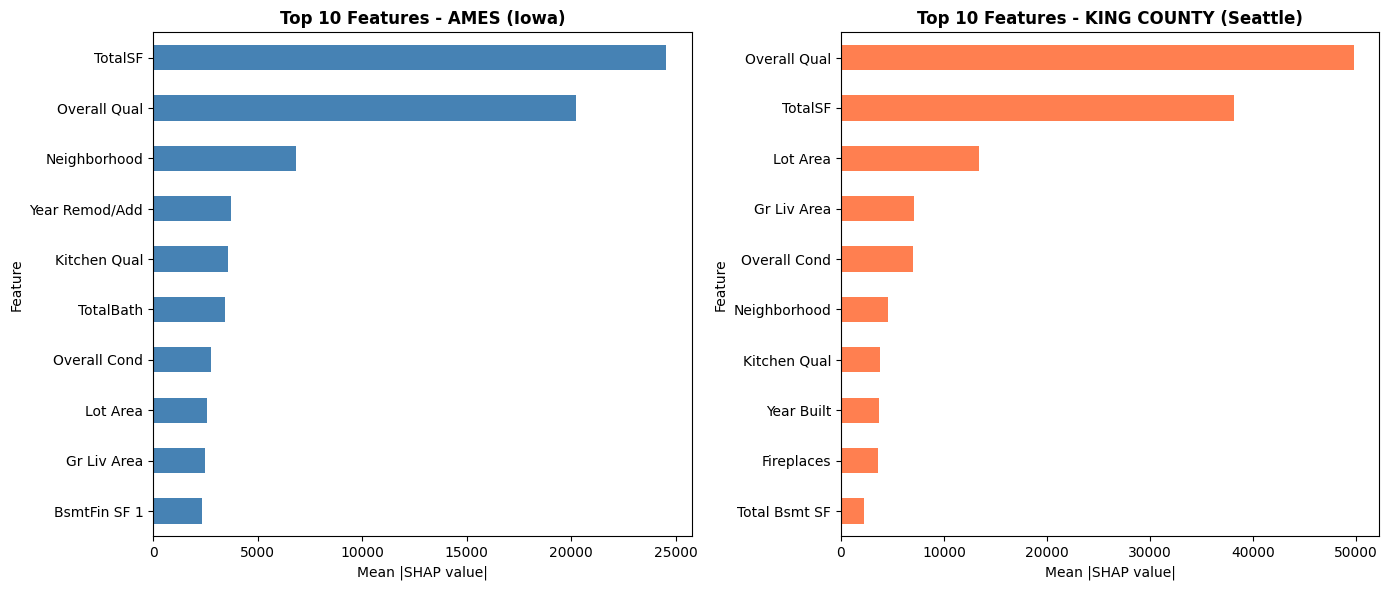

In [ ]:
# Compare top 10 features side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ames
ames_top_features.head(10).plot(kind='barh', x='Feature', y='SHAP',
                                 ax=ax1, color='steelblue', legend=False)
ax1.set_title('Top 10 Features - AMES (Iowa)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mean |SHAP value|')
ax1.invert_yaxis()

# King County
kc_top_features.head(10).plot(kind='barh', x='Feature', y='SHAP',
                               ax=ax2, color='coral', legend=False)
ax2.set_title('Top 10 Features - KING COUNTY (Seattle)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mean |SHAP value|')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Housing_Project/shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding:

Feature importance shifts dramatically between regions:
- Overall Qual (grade) becomes 2.5x more important in Seattle (SHAP 49.8k vs 20.2k)
- TotalSF dominates in Iowa but drops to #2 in Seattle
- Seattle market prioritizes quality ratings over pure square footage

This demonstrates market-specific feature importance — what matters in Iowa does not necessarily matter equally in Seattle.
"""

### 7.6 BONUS — Fine-Tune XGBoost on King County Data


In [ ]:
#Train XGBoost natively on King County data
print("=== Fine-tuning on King County ===\n")

# Split King County into train/test
from sklearn.model_selection import train_test_split

X_kc = kc_processed
y_kc = kc['price']

X_kc_train, X_kc_test, y_kc_train, y_kc_test = train_test_split(
    X_kc, y_kc, test_size=0.2, random_state=42
)

print(f"King County train: {X_kc_train.shape}")
print(f"King County test: {X_kc_test.shape}")

# Train XGBoost on King County
from xgboost import XGBRegressor

kc_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

kc_xgb.fit(X_kc_train, y_kc_train)

# Predict on King County test set
kc_native_pred = kc_xgb.predict(X_kc_test)

# Calculate metrics
kc_native_rmse = np.sqrt(mean_squared_error(y_kc_test, kc_native_pred))
kc_native_r2 = r2_score(y_kc_test, kc_native_pred)

print("\n=== Comparison ===")
print(f"BEFORE (Ames model on King County): RMSE ${492187:,.0f}, R² -0.797")
print(f"AFTER (Native King County model):   RMSE ${kc_native_rmse:,.0f}, R² {kc_native_r2:.3f}")

=== Fine-tuning on King County ===

King County train: (17290, 174)
King County test: (4323, 174)

=== Comparison ===
BEFORE (Ames model on King County): RMSE $492,187, R² -0.797
AFTER (Native King County model):   RMSE $230,890, R² 0.647


### Finding:

Native training on King County improves performance significantly (RMSE $231k vs $492k), but still worse than Ames performance ($22k). The gap is due to:
1. Only 9 real features available (165 filled with defaults)
2. Higher price variance in Seattle market
3. Dataset size difference (Ames 2930 vs KC 21613 rows helps, but feature quality matters more)

### 7.7 Phase 7 Summary


In [ ]:
# Final Phase 7 summary
summary = pd.DataFrame({
    'Scenario': [
        'XGBoost on Ames test (baseline)',
        'XGBoost transfer to King County',
        'Random Forest transfer to King County',
        'Linear Regression transfer to King County',
        'XGBoost trained natively on King County'
    ],
    'RMSE': [22108, 492187, 510548, 170828500, 230890],
    'R²': [0.931, -0.797, -0.934, -216523.68, 0.647],
    'Notes': [
        'Best performance - same region',
        'Poor transfer - feature mismatch',
        'Slightly worse transfer',
        'Complete failure - extrapolation',
        'Much better with native training'
    ]
})

print("=== PHASE 7 COMPLETE - SUMMARY ===\n")
print(summary.to_string(index=False))

=== PHASE 7 COMPLETE - SUMMARY ===

                                 Scenario      RMSE          R²                            Notes
          XGBoost on Ames test (baseline)     22108       0.931   Best performance - same region
          XGBoost transfer to King County    492187      -0.797 Poor transfer - feature mismatch
    Random Forest transfer to King County    510548      -0.934          Slightly worse transfer
Linear Regression transfer to King County 170828500 -216523.680 Complete failure - extrapolation
  XGBoost trained natively on King County    230890       0.647 Much better with native training


### Key Takeaways:

1. **Cross-regional transfer fails**: Models trained on Iowa cannot predict Seattle prices (negative R²)

2. **Feature availability matters**: Only 9/174 features available from King County; missing 165 features filled with Ames defaults

3. **XGBoost transfers best**: Complex models handle distribution shift better than simple linear models

4. **Feature importance shifts**: Seattle prioritizes quality (grade) 2.5x more than Iowa

5. **Native training helps**: Training on target region improves RMSE from $492k → $231k, but still limited by feature quality

This analysis demonstrates real-world ML challenges: models don't magically generalize across geographic regions with different feature sets and market dynamics.